# 02 — Preparación y Limpieza de Datos

**Reto 2 — IA avanzada en Business Analytics | Odisea Data**

**Objetivo:** Transformar el dataset crudo en un conjunto de datos listo para el entrenamiento de modelos de IA.

**Tareas:**
1. Carga del dataset original.
2. Tratamiento de outliers.
3. Codificación de variables categóricas.
4. Escalado de variables numéricas.
5. División train/test estratificada.
6. Guardado del dataset procesado.

In [2]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# ============================================================
# CARGA DEL DATASET ORIGINAL
# ============================================================
df = pd.read_csv("/content/train.csv")

print(f"📊 Dimensiones iniciales: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

📊 Dimensiones iniciales: 381,109 filas × 12 columnas


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
# ============================================================
# ELIMINAR COLUMNAS IRRELEVANTES
# ============================================================
# `id` es un identificador único: no aporta valor predictivo
df = df.drop(columns=["id"])
print(f"✅ Columna 'id' eliminada. Nuevas dimensiones: {df.shape}")

✅ Columna 'id' eliminada. Nuevas dimensiones: (381109, 11)


Percentil 1:  2,630.00
Percentil 99: 72,963.00

✅ Outliers tratados. Nueva distribución:
count    381109.000000
mean      30338.717275
std       15916.679308
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max       72963.000000
Name: Annual_Premium, dtype: float64


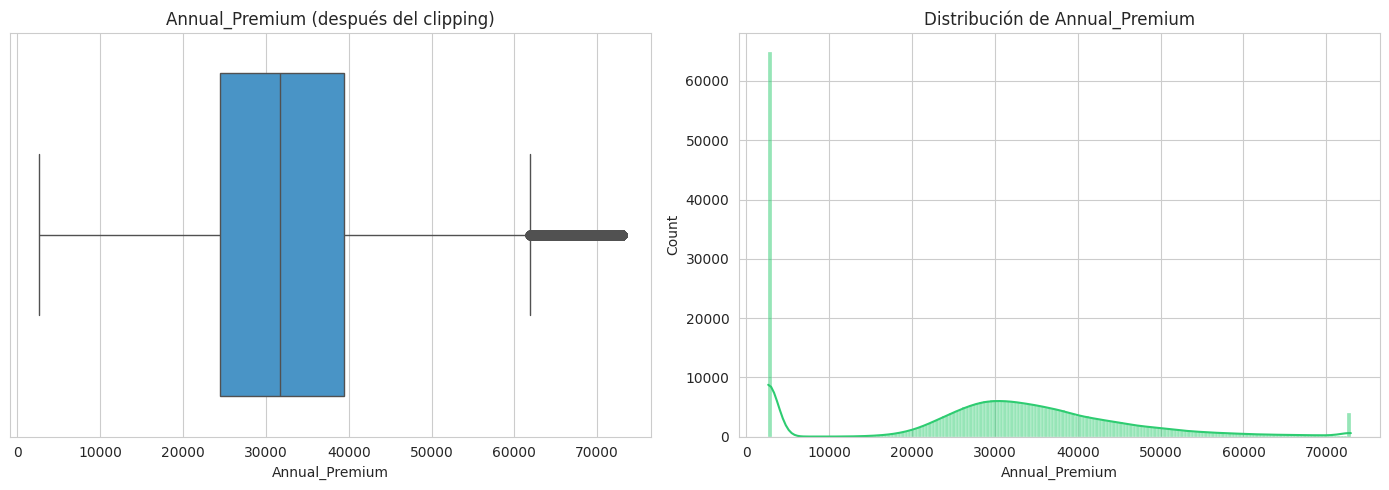

In [5]:
# ============================================================
# TRATAMIENTO DE OUTLIERS EN Annual_Premium
# ============================================================
# Estrategia: clipping (winsorizing) usando percentiles 1 y 99
# Esto reduce el impacto de valores extremos sin eliminar filas

q_low = df["Annual_Premium"].quantile(0.01)
q_high = df["Annual_Premium"].quantile(0.99)

print(f"Percentil 1:  {q_low:,.2f}")
print(f"Percentil 99: {q_high:,.2f}")

df["Annual_Premium"] = df["Annual_Premium"].clip(lower=q_low, upper=q_high)

print(f"\n✅ Outliers tratados. Nueva distribución:")
print(df["Annual_Premium"].describe())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["Annual_Premium"], ax=axes[0], color="#3498db")
axes[0].set_title("Annual_Premium (después del clipping)")
sns.histplot(df["Annual_Premium"], kde=True, ax=axes[1], color="#2ecc71")
axes[1].set_title("Distribución de Annual_Premium")
plt.tight_layout()
plt.savefig("annual_premium_after.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
# Estrategia:
# - Variables binarias (Gender, Vehicle_Damage): Label Encoding (0/1)
# - Variables ordinales (Vehicle_Age): mapeo ordenado
# - Vehicle_Age tiene orden: < 1 Year < 1-2 Year < > 2 Years

# 1. Gender → binaria
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# 2. Vehicle_Damage → binaria
df["Vehicle_Damage"] = df["Vehicle_Damage"].map({"No": 0, "Yes": 1})

# 3. Vehicle_Age → ordinal
vehicle_age_map = {
    "< 1 Year": 0,
    "1-2 Year": 1,
    "> 2 Years": 2,
}
df["Vehicle_Age"] = df["Vehicle_Age"].map(vehicle_age_map)

print("✅ Variables categóricas codificadas")
print("\nValores únicos por columna:")
for col in ["Gender", "Vehicle_Damage", "Vehicle_Age"]:
    print(f"  {col}: {sorted(df[col].unique())}")

✅ Variables categóricas codificadas

Valores únicos por columna:
  Gender: [np.int64(0), np.int64(1)]
  Vehicle_Damage: [np.int64(0), np.int64(1)]
  Vehicle_Age: [np.int64(0), np.int64(1), np.int64(2)]


In [7]:
# ============================================================
# SEPARAR FEATURES (X) Y TARGET (y)
# ============================================================
X = df.drop(columns=["Response"])
y = df["Response"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nDistribución de y:")
print(y.value_counts(normalize=True).round(4))

X shape: (381109, 10)
y shape: (381109,)

Distribución de y:
Response
0    0.8774
1    0.1226
Name: proportion, dtype: float64


In [8]:
# ============================================================
# SPLIT TRAIN/TEST ESTRATIFICADO
# ============================================================
# El parámetro stratify=y mantiene la proporción de clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"✅ Split realizado")
print(f"  Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribución de clases en train: {dict(y_train.value_counts(normalize=True).round(4))}")
print(f"Distribución de clases en test:  {dict(y_test.value_counts(normalize=True).round(4))}")

✅ Split realizado
  Train: 304,887 filas (80.0%)
  Test:  76,222 filas (20.0%)

Distribución de clases en train: {0: np.float64(0.8774), 1: np.float64(0.1226)}
Distribución de clases en test:  {0: np.float64(0.8774), 1: np.float64(0.1226)}


In [13]:
# ============================================================
# ESCALADO DE VARIABLES NUMÉRICAS
# ============================================================
# IMPORTANTE: el scaler se ajusta SOLO con train y se aplica a test
# (evitar data leakage)

num_cols = ["Age", "Annual_Premium", "Vintage", "Region_Code", "Policy_Sales_Channel"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("✅ Variables numéricas escaladas")
print("\nEstadísticas post-escalado (train):")
print(X_train_scaled[num_cols].describe().round(3).T)

✅ Variables numéricas escaladas

Estadísticas post-escalado (train):
                         count  mean  std    min    25%    50%    75%    max
Age                   304887.0   0.0  1.0 -1.213 -0.891 -0.182  0.656  2.976
Annual_Premium        304887.0  -0.0  1.0 -1.739 -0.374  0.084  0.569  2.672
Vintage               304887.0  -0.0  1.0 -1.726 -0.865 -0.005  0.868  1.728
Region_Code           304887.0  -0.0  1.0 -1.995 -0.861  0.121  0.650  1.935
Policy_Sales_Channel  304887.0  -0.0  1.0 -2.049 -1.533  0.405  0.737  0.940


In [10]:
# ============================================================
# GUARDAR DATASET PROCESADO
# ============================================================
# Guardamos el dataset completo procesado (X + y) en un solo CSV
df_train_final = X_train_scaled.copy()
df_train_final["Response"] = y_train.values

df_test_final = X_test_scaled.copy()
df_test_final["Response"] = y_test.values

df_train_final.to_csv("train_processed.csv", index=False)
df_test_final.to_csv("test_processed.csv", index=False)

print("✅ Datasets guardados:")
print(f"  train_processed.csv: {df_train_final.shape}")
print(f"  test_processed.csv:  {df_test_final.shape}")

✅ Datasets guardados:
  train_processed.csv: (304887, 11)
  test_processed.csv:  (76222, 11)


In [11]:
# ============================================================
# GUARDAR SCALER (CRÍTICO PARA PRODUCCIÓN)
# ============================================================
# El scaler debe guardarse para poder transformar datos nuevos
# con la misma escala usada durante el entrenamiento

os.makedirs("models/scalers", exist_ok=True)
joblib.dump(scaler, "models/scalers/scaler.pkl")

print("✅ Scaler guardado en models/scalers/scaler.pkl")

✅ Scaler guardado en models/scalers/scaler.pkl


In [12]:
# ============================================================
# DESCARGAR ARTEFACTOS
# ============================================================
import zipfile
from google.colab import files

archivos = [
    "train_processed.csv",
    "test_processed.csv",
    "annual_premium_after.png",
    "models/scalers/scaler.pkl",
]

with zipfile.ZipFile("preparacion_artefactos.zip", "w") as zipf:
    for a in archivos:
        if os.path.exists(a):
            zipf.write(a)
            print(f"✅ {a}")
        else:
            print(f"⚠️  NO encontrado: {a}")

files.download("preparacion_artefactos.zip")

✅ train_processed.csv
✅ test_processed.csv
✅ annual_premium_after.png
✅ models/scalers/scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Conclusiones de la Preparación

### Transformaciones aplicadas
- **Columna `id` eliminada** → no aporta valor predictivo.
- **Outliers en `Annual_Premium`** tratados por clipping (percentiles 1-99).
- **Variables categóricas codificadas:**
  - `Gender` → 0/1
  - `Vehicle_Damage` → 0/1
  - `Vehicle_Age` → ordinal (0, 1, 2)
- **Split estratificado 80/20** para preservar el desbalanceo de clases.
- **Escalado `StandardScaler`** ajustado solo con train (sin data leakage).

### Artefactos generados
| Archivo | Descripción |
|---|---|
| `train_processed.csv` | Dataset de entrenamiento limpio |
| `test_processed.csv` | Dataset de test limpio |
| `scaler.pkl` | Scaler entrenado para producción |
| `annual_premium_after.png` | Gráfico de la distribución tratada |

### Próximos pasos (notebook 03)
1. Entrenamiento de **Random Forest** con `class_weight="balanced"`.
2. Entrenamiento de **XGBoost** con `scale_pos_weight`.
3. Entrenamiento de **LightGBM**.
4. Validación cruzada con `StratifiedKFold`.